In [2]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import RFE
from lightgbm import LGBMRegressor

import shap


c:\Users\Ridwan Sharif\Documents\University_space\Defence\models\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# If not already loaded
df = pd.read_csv("ppg_features_with_demographics.csv")

# Features = all non-target numeric columns
targets = ["systolic_BP", "diastolic_BP"]
feature_cols = [c for c in df.columns if c not in targets and c != "row_index"]

X = df[feature_cols].select_dtypes(include=[np.number]).fillna(0)
y_sys = df["systolic_BP"].values
y_dia = df["diastolic_BP"].values


In [4]:
def mi_ranking(X, y, top_k=30):
    mi = mutual_info_regression(X, y, random_state=42)
    mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
    return mi_series.head(top_k)

print("Top MI for Systolic:")
print(mi_ranking(X, y_sys))

print("\nTop MI for Diastolic:")
print(mi_ranking(X, y_dia))


Top MI for Systolic:
userBmi                      0.145467
userWeight                   0.102618
amplitude_max                0.062785
width_sec_std                0.041512
rmssd                        0.033576
notch_time_from_peak_std     0.032140
rise_fall_ratio_mean         0.032083
petrosian_fd                 0.031074
auc_max                      0.029349
userHeight                   0.029200
dfa_alpha                    0.027098
hf_energy                    0.024815
total_power                  0.023584
notch_time_from_peak_mean    0.022846
shannon_entropy              0.022582
hjorth_activity              0.021860
fall_time_sec_min            0.021508
bpm_mean                     0.018702
amplitude_min                0.017925
spec_centroid_hz             0.016013
userGender                   0.014449
amplitude_mean               0.013111
rise_time_sec_std            0.012733
fall_time_sec_max            0.012533
num_beats                    0.010433
n_valid_beats                

In [5]:
def rfe_selection(X, y, n_features=20):
    model = LGBMRegressor(random_state=42, n_estimators=300)
    selector = RFE(model, n_features_to_select=n_features, step=1)
    selector.fit(X, y)
    selected = X.columns[selector.support_]
    return selected

selected_sys = rfe_selection(X, y_sys, n_features=20)
selected_dia = rfe_selection(X, y_dia, n_features=20)

print("Selected features for Systolic:", selected_sys.tolist())
print("Selected features for Diastolic:", selected_dia.tolist())


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000834 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5908
[LightGBM] [Info] Number of data points in the train set: 317, number of used features: 81
[LightGBM] [Info] Start training from score 120.719243
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

SHAP for Systolic:
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1694
[LightGBM] [Info] Number of data points in the train set: 317, number of used features: 20
[LightGBM] [Info] Start training from score 120.719243
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

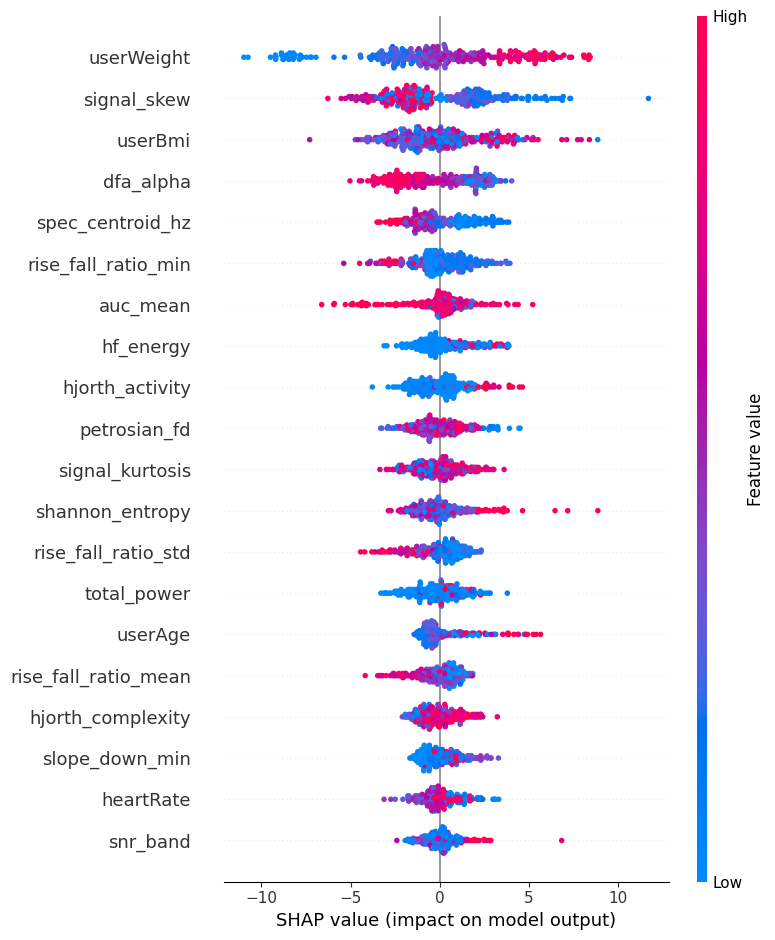

SHAP for Diastolic:
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1646
[LightGBM] [Info] Number of data points in the train set: 317, number of used features: 20
[LightGBM] [Info] Start training from score 78.996845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

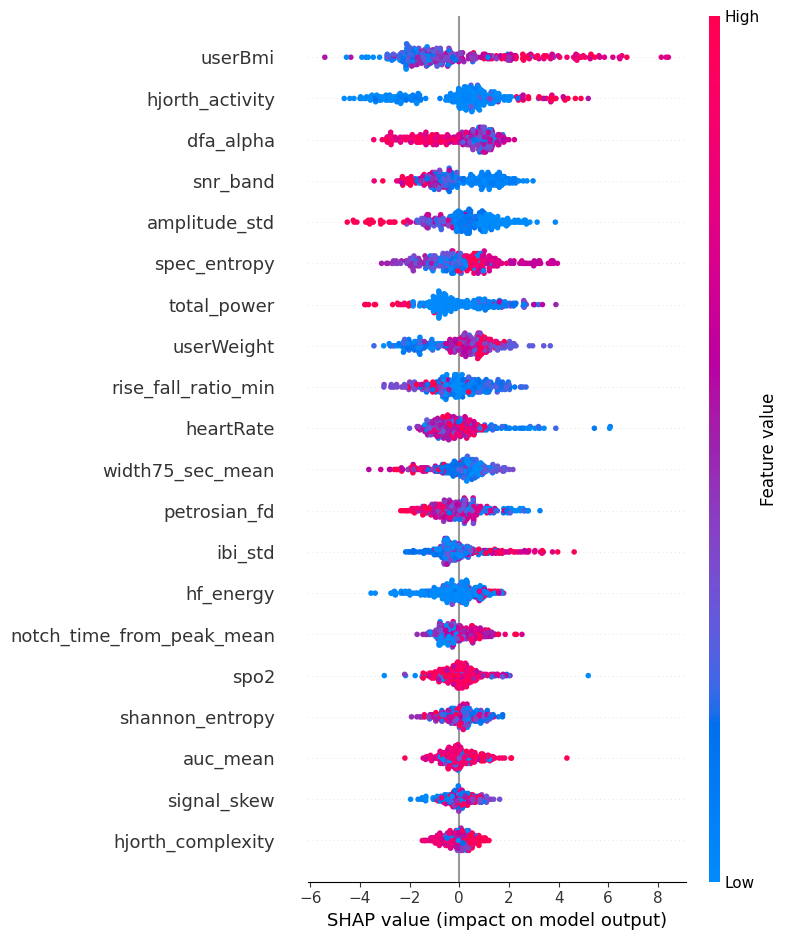

In [6]:
def shap_analysis(X, y, n_features=20):
    model = LGBMRegressor(random_state=42, n_estimators=500)
    model.fit(X, y)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    shap.summary_plot(shap_values, X, max_display=n_features)
    return model, shap_values

print("SHAP for Systolic:")
model_sys, shap_sys = shap_analysis(X[selected_sys], y_sys)

print("SHAP for Diastolic:")
model_dia, shap_dia = shap_analysis(X[selected_dia], y_dia)


In [7]:
from sklearn.metrics import mean_absolute_error

def cv_mae(X, y, model=None, n_splits=5):
    if model is None:
        model = LGBMRegressor(random_state=42, n_estimators=500)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")
    return scores.mean(), scores.std()

print("CV MAE (Sys, 20 features):", cv_mae(X[selected_sys], y_sys))
print("CV MAE (Dia, 20 features):", cv_mae(X[selected_dia], y_dia))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1392
[LightGBM] [Info] Number of data points in the train set: 253, number of used features: 20
[LightGBM] [Info] Start training from score 120.142292
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [33]:
selected_sys = rfe_selection(X, y_sys, n_features=20)
selected_dia = rfe_selection(X, y_dia, n_features=20)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2055
[LightGBM] [Info] Number of data points in the train set: 317, number of used features: 25
[LightGBM] [Info] Start training from score 120.719243
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [34]:
# Reduced systolic dataset
reduced_sys_df = pd.concat([
    X[selected_sys], 
    df[["systolic_BP"]]
], axis=1)

# Reduced diastolic dataset
reduced_dia_df = pd.concat([
    X[selected_dia], 
    df[["diastolic_BP"]]
], axis=1)


In [35]:
print(reduced_sys_df.shape)
print(reduced_dia_df.shape)

(317, 21)
(317, 21)


In [18]:
reduced_sys_df.to_csv("reduced25_features_systolic.csv", index=False)
reduced_dia_df.to_csv("reduced25_features_diastolic.csv", index=False)

print("✅ Saved reduced datasets")


✅ Saved reduced datasets


In [36]:
selected_all = list(set(selected_sys) | set(selected_dia))

reduced_all_df = pd.concat([
    X[selected_all], 
    df[["systolic_BP", "diastolic_BP"]]
], axis=1)




In [37]:
print("reduced_all_df shape:", reduced_all_df.shape)

reduced_all_df shape: (317, 26)


In [ ]:
reduced_all_df.to_csv("reduced20_features_all.csv", index=False)
print("✅ Saved combined reduced dataset")

In [22]:
display(reduced_all_df.head())

,hjorth_complexity,notch_time_from_peak_mean,rmssd,rise_time_sec_std,width25_sec_max,rise_fall_ratio_mean,snr_band,spec_entropy,userBmi,userHeight,...,slope_down_min,spec_centroid_hz,amplitude_min,petrosian_fd,userWeight,amplitude_std,signal_skew,signal_kurtosis,systolic_BP,diastolic_BP
0,4.001636,0.433333,4.031956,0.563205,1.52,1.447017,0.511488,1.669894,30.246914,180.0,...,421.233381,0.447554,747.778750,1.003312,98,948.709071,-0.770381,4.742569,122,83
1,1.972410,0.200000,1.053717,0.851939,2.30,3.220168,1.414937,1.946771,18.131219,154.0,...,1045.709338,0.540890,528.496336,1.003657,43,724.255864,-3.598377,20.221196,102,68
2,4.060577,0.280000,16.340000,0.000000,9.88,0.258216,0.464499,1.340952,29.899691,144.0,...,91.458833,0.377567,882.237858,1.003110,62,0.000000,-1.173296,5.468573,141,93
3,4.217725,0.370000,5.360191,0.725259,3.12,2.286036,0.385128,1.170405,34.816117,172.0,...,34.093313,0.315293,124.669218,1.002619,103,71.694957,1.199089,6.051679,139,96
4,4.074945,0.340000,1.531535,6.873078,14.64,0.881611,0.456426,1.308824,29.745809,172.0,...,122.251528,0.323768,671.969036,1.002966,88,18.251657,-1.328065,5.571871,112,75


In [47]:
display(reduced_all_df.head())

,hjorth_complexity,rmssd,rise_time_sec_std,width25_sec_max,rise_fall_ratio_mean,snr_band,userBmi,sampen,dfa_alpha,shannon_entropy,...,auc_mean,heartRate,slope_down_min,spec_centroid_hz,petrosian_fd,userWeight,signal_skew,signal_kurtosis,systolic_BP,diastolic_BP
0,4.001636,4.031956,0.563205,1.52,1.447017,0.511488,30.246914,0.104575,1.507373,2.508408,...,540.919492,107.0,421.233381,0.447554,1.003312,98,-0.770381,4.742569,122,83
1,1.972410,1.053717,0.851939,2.30,3.220168,1.414937,18.131219,0.107798,1.435343,1.983938,...,61.261886,125.0,1045.709338,0.540890,1.003657,43,-3.598377,20.221196,102,68
2,4.060577,16.340000,0.000000,9.88,0.258216,0.464499,29.899691,0.078157,1.523073,2.555868,...,-801.617884,93.0,91.458833,0.377567,1.003110,62,-1.173296,5.468573,141,93
3,4.217725,5.360191,0.725259,3.12,2.286036,0.385128,34.816117,0.055588,1.579549,2.456420,...,-26.304996,71.0,34.093313,0.315293,1.002619,103,1.199089,6.051679,139,96
4,4.074945,1.531535,6.873078,14.64,0.881611,0.456426,29.745809,0.055869,1.602709,2.577495,...,-602.730413,166.0,122.251528,0.323768,1.002966,88,-1.328065,5.571871,112,75


In [ ]:
df.isnull().sum()

amplitude_mean    68
amplitude_std     91
amplitude_min     68
amplitude_max     68
width_sec_mean    68
                  ..
userHeight         0
userWeight         0
userBmi            0
systolic_BP        0
diastolic_BP       0
Length: 85, dtype: int64

: 

In [45]:
# --- CONFIGURE YOUR EXPERIMENT HERE ---

# pick which dataset to use (merged_df = full features, reduced_all_df = feature-selected)
SELECTED_DF_NAME = df   # or reduced_all_df, or feature_df

# choose target(s) to predict
# can be one or both: ['systolic_BP'], ['diastolic_BP'], or ['systolic_BP','diastolic_BP']
SELECTED_TARGET = ['systolic_BP', 'diastolic_BP']

# --- END OF CONFIGURATION ---


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features/labels split
X = SELECTED_DF_NAME.drop(columns=SELECTED_TARGET)  # drop row_index if it exists
y = SELECTED_DF_NAME[SELECTED_TARGET]

print(f"✅ Selected Features: {X.shape[1]} (Shape: {X.shape})")
print(f"✅ Selected Target: {SELECTED_TARGET} (Shape: {y.shape})")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize (fit only on training set!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data split and scaled successfully.")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")


✅ Selected Features: 83 (Shape: (317, 83))
✅ Selected Target: ['systolic_BP', 'diastolic_BP'] (Shape: (317, 2))
✅ Data split and scaled successfully.
Training features shape: (253, 83)
Testing features shape: (64, 83)


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_regression_metrics(y_true, y_pred):
    """Return common regression metrics as a dict."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    # Safe MAPE (ignore zeros in denominator)
    denom = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2,
        "MAPE Score(%)": mape
    }

def plot_model_performance(y_test, y_pred, model_name, target_name):
    """Plot True vs Pred, Residuals, and Error CDF."""
    y_test = np.asarray(y_test).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # True vs Pred
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--', lw=2)
    plt.title(f'True vs. Predicted\n({model_name})')
    plt.xlabel(f'True {target_name} (mmHg)')
    plt.ylabel(f'Predicted {target_name} (mmHg)')
    plt.grid(True)

    # Residuals
    residuals = y_test - y_pred
    plt.subplot(1, 3, 2)
    plt.scatter(y_pred, residuals, alpha=0.6, edgecolors='k')
    plt.axhline(0, color='r', linestyle='--', lw=2)
    plt.title(f'Residuals Plot\n({model_name})')
    plt.xlabel('Predicted Values (mmHg)')
    plt.ylabel('Residuals (True - Pred)')
    plt.grid(True)

    # Error CDF
    abs_err = np.abs(residuals)
    sorted_err = np.sort(abs_err)
    cdf = np.arange(len(sorted_err)) / len(sorted_err)
    plt.subplot(1, 3, 3)
    plt.plot(sorted_err, cdf, lw=2)
    plt.title(f'Accuracy Curve (Error CDF)\n({model_name})')
    plt.xlabel('Absolute Error (mmHg)')
    plt.ylabel('Proportion of Test Samples')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("✅ Helper functions (metrics + plots) are defined. Now re-run the test harness cell.")


✅ Helper functions (metrics + plots) are defined. Now re-run the test harness cell.


In [46]:
# If needed (run once in a cell):
# !pip install lightgbm catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------- your helper functions (already defined) ----------
# calculate_regression_metrics(...)
# plot_model_performance(...)

# ---------- models to compare ----------
models = {
    "Linear":        LinearRegression(),
    "Ridge":         Ridge(alpha=1.0, random_state=42),
    "RandomForest":  RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "LightGBM":      LGBMRegressor(n_estimators=600, learning_rate=0.05, random_state=42),
    "CatBoost":      CatBoostRegressor(
                        iterations=800, learning_rate=0.05, depth=6,
                        loss_function="RMSE", random_seed=42, verbose=False)
}

def run_benchmark_for_target(target_name):
    """
    Trains/evaluates all models for one target and returns a metrics DataFrame.
    Also plots True vs Pred / Residuals / Error-CDF for each model.
    """
    # ensure 1D arrays for sklearn/catboost
    ytr = np.asarray(y_train[target_name]).ravel()
    yte = np.asarray(y_test[target_name]).ravel()

    records = []
    for name, model in models.items():
        # fit
        model.fit(X_train_scaled, ytr)
        # predict
        y_pred = model.predict(X_test_scaled)
        # metrics
        m = calculate_regression_metrics(yte, y_pred)
        m["Model"] = name
        m["Target"] = target_name
        records.append(m)
        # plots
        plot_model_performance(yte, y_pred, model_name=name, target_name=target_name)

    df_metrics = pd.DataFrame(records).set_index(["Target", "Model"]).sort_values(["Target","MAE"])
    return df_metrics

# ---------- run for all selected targets ----------
all_results = []
for tgt in SELECTED_TARGET:
    res = run_benchmark_for_target(tgt)
    display(res)
    all_results.append(res)

results_df = pd.concat(all_results)
print("✅ Done. Combined metrics:")
display(results_df)


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# 1. Initialize and Train the Model
model_name = 'Random Forest'
rf_model = RandomForestRegressor(n_estimators=300, random_state=22)
rf_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# 3. Evaluate Performance and Store Results
metrics_rf = calculate_regression_metrics(y_test, y_pred_rf)
all_model_results[model_name] = metrics_rf
print(f"--- {model_name} Performance ---")
for metric, value in metrics_rf.items():
    print(f"{metric}: {value:.4f}")

# 4. Plot Performance
plot_model_performance(y_test, y_pred_rf, model_name, SELECTED_TARGET)

TypeError: list indices must be integers or slices, not str

In [ ]:
# Plot R-squared
plt.figure(figsize=(10, 6))
results_df['R²'].sort_values(ascending=False).plot(kind='bar', color=sns.color_palette("viridis", len(results_df)))
plt.title(f'Model Performance Comparison for {SELECTED_TARGET}\nR-squared ($R^2$) Comparison', fontsize=14)
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Plot MAE (lower is better)
plt.figure(figsize=(10, 6))
results_df['MAE'].sort_values(ascending=True).plot(kind='bar', color=sns.color_palette("plasma", len(results_df)))
plt.title(f'Model Performance Comparison for {SELECTED_TARGET}\nMean Absolute Error (MAE) Comparison', fontsize=14)
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()